# **Практическое задание №3: Линейная регрессия и функции потерь / Байкалов Сергей Андреевич / 925-М**

***Общее описание задания***

***Тема:*** Исследование влияния функций потерь и гиперпараметров на качество линейной регрессии

***Цель:*** Научиться применять линейную регрессию для решения задач прогнозирования, анализировать влияние выбросов, сравнивать различные функции потерь и подбирать оптимальные гиперпараметры.



### Этап 1: Генерация и подготовка данных
1. Сгенерируйте синтетический датасет согласно вашему варианту
2. Добавьте шум и выбросы в соответствии с параметрами варианта
3. Разделите данные на обучающую и тестовую выборки (70/30)
4. Выполните масштабирование признаков

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# функция генерации из задания
def generate_dataset(n_samples=500, n_features=2, noise_std=0.5,
                     outlier_fraction=0.05, outlier_multiplier=3,
                     random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)

    X = np.random.randn(n_samples, n_features)

    true_coef = np.random.uniform(1, 5, n_features)
    true_intercept = np.random.uniform(0, 10)

    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std

    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)

    y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * \
                      np.random.uniform(3, 10, n_outliers) * outlier_multiplier

    return X, y, true_coef, true_intercept


# генерация датасета
features = ["area", "rooms"]
target = "price"

X, y, true_w, true_b = generate_dataset(
    n_samples=500,
    n_features=2,
    noise_std=0.5,
    outlier_fraction=0.05,
    outlier_multiplier=3,
    random_seed=1
)

# формируем DataFrame
df = pd.DataFrame(X, columns=features)
df[target] = y

print("Первые строки датасета:")
display(df.head())

print("Истинные коэффициенты модели:")
print("weights:", true_w)
print("intercept:", true_b)

Первые строки датасета:


,area,rooms,price
0,1.624345,-0.611756,4.729969
1,-0.528172,-1.072969,-1.543462
2,0.865408,-2.301539,-1.561585
3,1.744812,-0.761207,4.236869
4,0.319039,-0.249370,2.513072


Истинные коэффициенты модели:
weights: [2.54795694 2.97152349]
intercept: 2.544381023144221


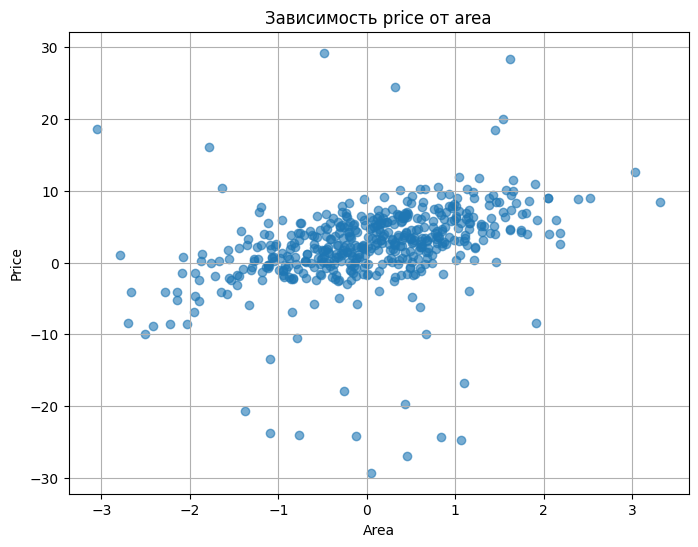

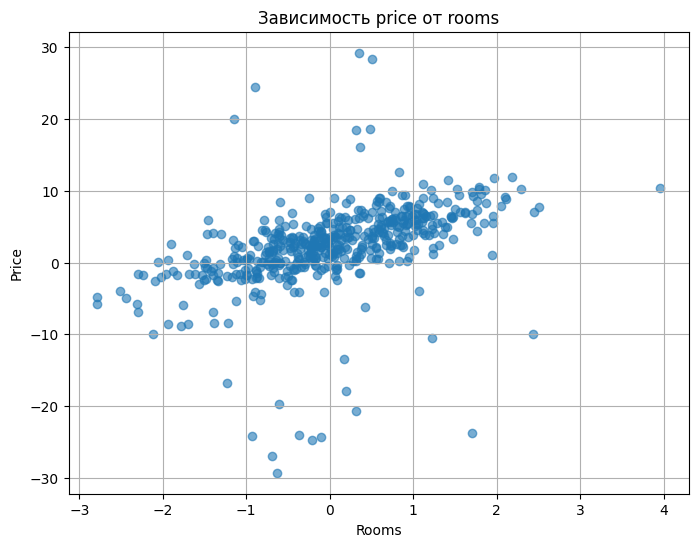

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["area"], df["price"], alpha=0.6)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Зависимость price от area")
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df["rooms"], df["price"], alpha=0.6)
plt.xlabel("Rooms")
plt.ylabel("Price")
plt.title("Зависимость price от rooms")
plt.grid()
plt.show()

In [ ]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (350, 2)
Test shape: (150, 2)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

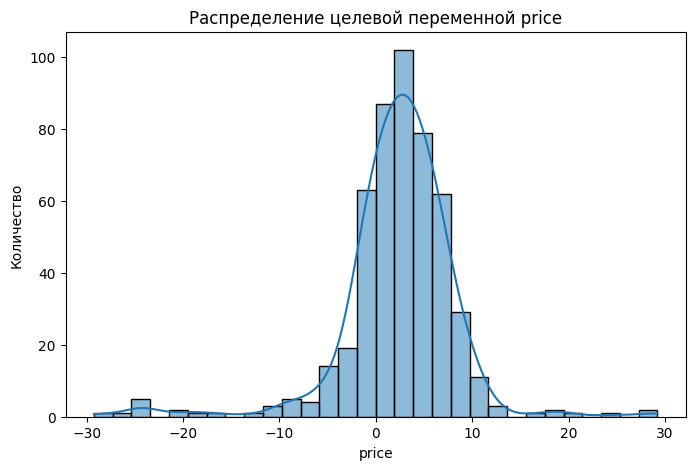

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Распределение целевой переменной price")
plt.xlabel("price")
plt.ylabel("Количество")
plt.show()

### Этап 2: Разведочный анализ данных (EDA)
1. Постройте матрицу корреляций признаков (heatmap)
2. Создайте pairplot для визуализации линейных зависимостей
3. Проанализируйте распределение целевой переменной
4. Выявите и визуализируйте выбросы

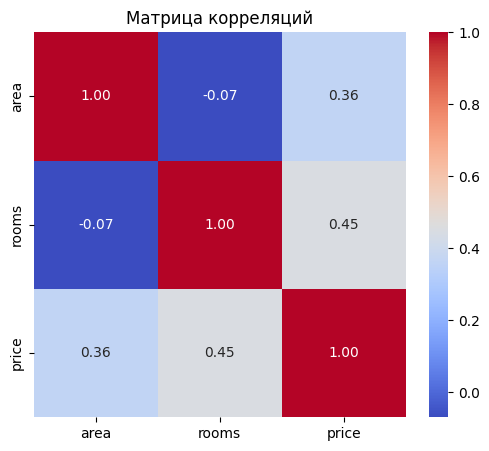

In [ ]:
plt.figure(figsize=(6,5))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Матрица корреляций")
plt.show()

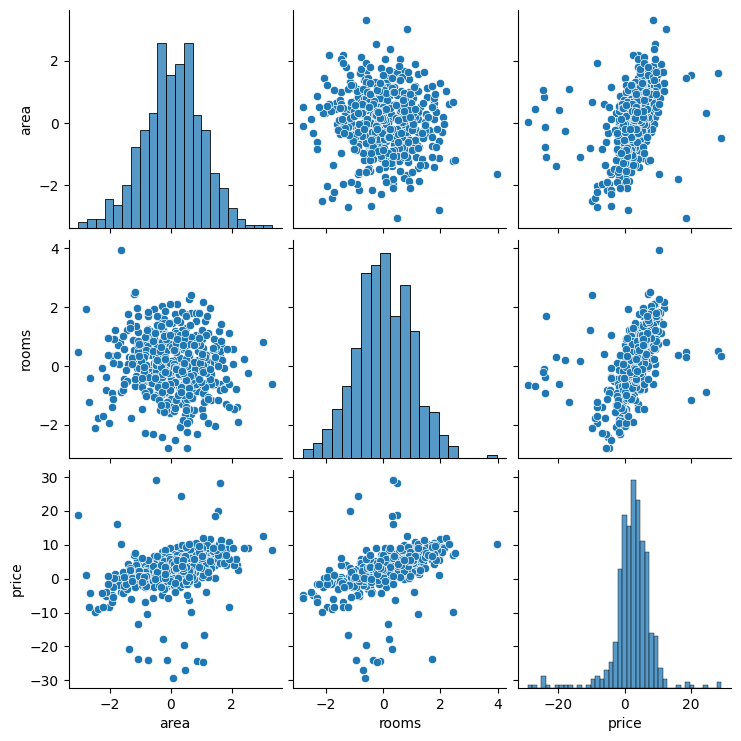

In [ ]:
sns.pairplot(df)

plt.show()

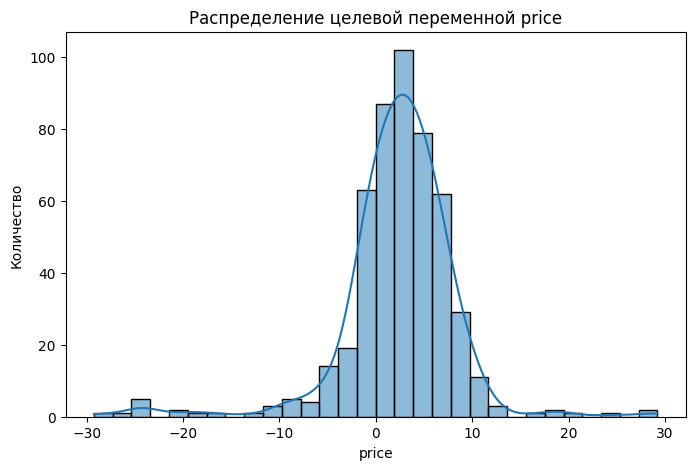

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Распределение целевой переменной price")
plt.xlabel("price")
plt.ylabel("Количество")
plt.show()

Распределение целевой переменной близко к нормальному, однако наблюдаются отдельные экстремальные значения. Эти значения вызваны искусственно добавленными выбросами и приводят к увеличению дисперсии распределения.

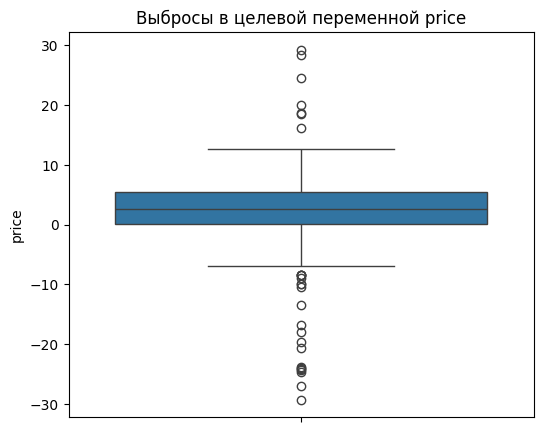

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["price"])

plt.title("Выбросы в целевой переменной price")

plt.show()


### Этап 3: Обучение моделей
1. Обучите три модели:
   - `LinearRegression` (минимизация MSE)
   - `HuberRegressor` с параметром `epsilon` из варианта
   - `SGDRegressor` с параметром `loss` из варианта
2. Зафиксируйте коэффициенты модели и свободный член

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import SGDRegressor

model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("LinearRegression")

print("coefficients:", model_lr.coef_)
print("intercept:", model_lr.intercept_)

LinearRegression
coefficients: [2.31133106 3.01713413]
intercept: 2.609925539255204


In [ ]:
epsilon = 1.35
model_huber = HuberRegressor(epsilon=1.35)

model_huber.fit(X_train_scaled, y_train)

y_pred_huber = model_huber.predict(X_test_scaled)


print("HuberRegressor")

print("coefficients:", model_huber.coef_)
print("intercept:", model_huber.intercept_)

HuberRegressor
coefficients: [2.56984754 3.01054579]
intercept: 2.8475380528050596


In [ ]:
loss = "huber"
model_sgd = SGDRegressor(
    loss=loss,
    max_iter=1000,
    random_state=42
)

model_sgd.fit(X_train_scaled, y_train)

y_pred_sgd = model_sgd.predict(X_test_scaled)


print("SGDRegressor")

print("coefficients:", model_sgd.coef_)
print("intercept:", model_sgd.intercept_)

SGDRegressor
coefficients: [1.85458037 2.27354976]
intercept: [2.2873248]


In [ ]:
coef_table = pd.DataFrame({
    "Model": ["LinearRegression","HuberRegressor","SGDRegressor"],
    "coef_area": [
        model_lr.coef_[0],
        model_huber.coef_[0],
        model_sgd.coef_[0]],

    "coef_rooms": [
        model_lr.coef_[1],
        model_huber.coef_[1],
        model_sgd.coef_[1]],

    "intercept": [
        model_lr.intercept_,
        model_huber.intercept_,
        model_sgd.intercept_]})

coef_table

,Model,coef_area,coef_rooms,intercept
0,LinearRegression,2.311331,3.017134,2.609926
1,HuberRegressor,2.569848,3.010546,2.847538
2,SGDRegressor,1.854580,2.273550,[2.2873248008052522]


### Этап 4: Оценка качества
1. Рассчитайте метрики на тестовой выборке:
   - MSE, RMSE, MAE, R²
2. Постройте графики:
   - Фактические vs предсказанные значения
   - Остатки модели (residual plot)
   - Сравнение предсказаний трёх моделей


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

metrics = pd.DataFrame(columns=["Model","MSE","RMSE","MAE","R2"])

def calculate_metrics(name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame([[name, mse, rmse, mae, r2]],
                        columns=["Model","MSE","RMSE","MAE","R2"])

metrics = pd.concat([
    calculate_metrics("LinearRegression", y_test, y_pred_lr),
    calculate_metrics("HuberRegressor", y_test, y_pred_huber),
    calculate_metrics("SGDRegressor", y_test, y_pred_sgd)
])

metrics

,Model,MSE,RMSE,MAE,R2
0,LinearRegression,21.191956,4.603472,1.283902,0.316642
0,HuberRegressor,21.389636,4.624893,1.201661,0.310268
0,SGDRegressor,21.322487,4.617628,1.658015,0.312433


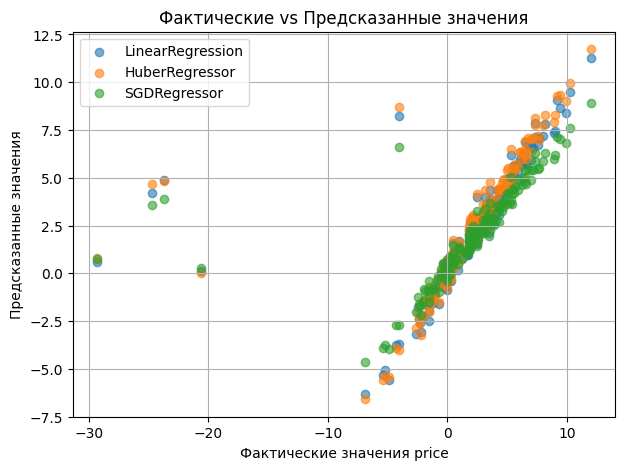

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr, alpha=0.6, label="LinearRegression")
plt.scatter(y_test, y_pred_huber, alpha=0.6, label="HuberRegressor")
plt.scatter(y_test, y_pred_sgd, alpha=0.6, label="SGDRegressor")

plt.xlabel("Фактические значения price")
plt.ylabel("Предсказанные значения")

plt.title("Фактические vs Предсказанные значения")

plt.legend()
plt.grid(True)

plt.show()

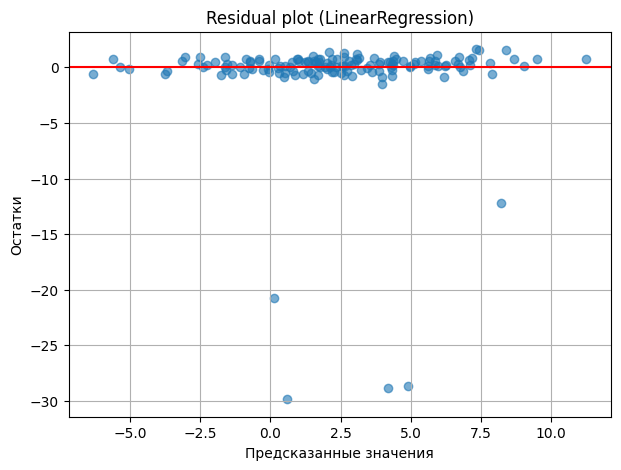

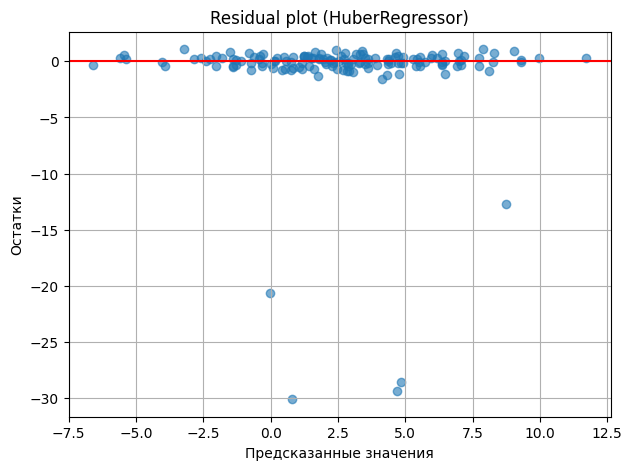

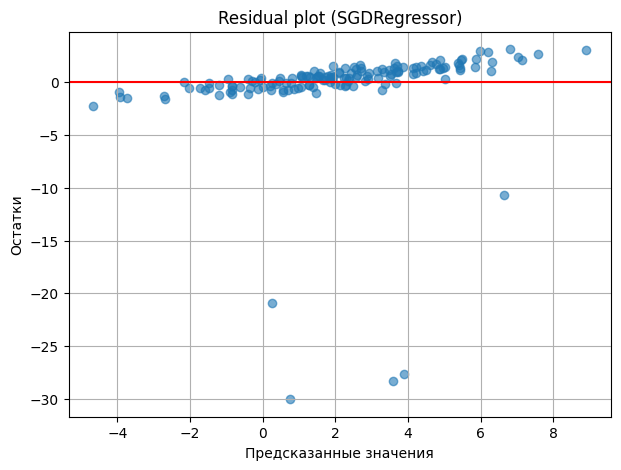

In [ ]:
residuals_lr = y_test - y_pred_lr
residuals_huber = y_test - y_pred_huber
residuals_sgd = y_test - y_pred_sgd

plt.figure(figsize=(7,5))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Residual plot (LinearRegression)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_pred_huber, residuals_huber, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Residual plot (HuberRegressor)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_pred_sgd, residuals_sgd, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Residual plot (SGDRegressor)")
plt.grid(True)
plt.show()

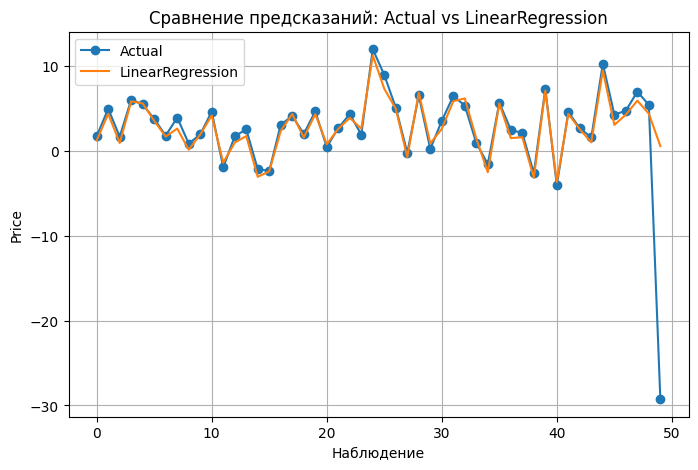

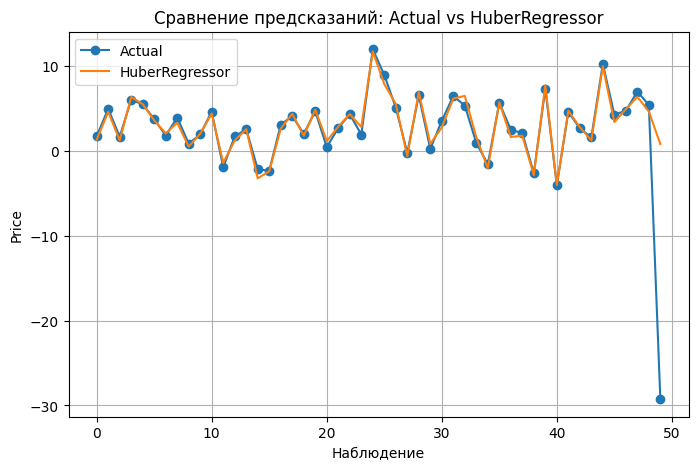

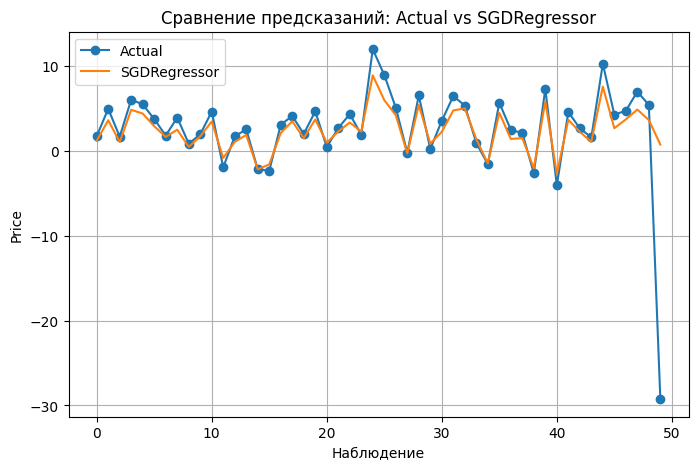

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_lr[:50], label="LinearRegression")
plt.title("Сравнение предсказаний: Actual vs LinearRegression")
plt.xlabel("Наблюдение")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_huber[:50], label="HuberRegressor")
plt.title("Сравнение предсказаний: Actual vs HuberRegressor")
plt.xlabel("Наблюдение")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_sgd[:50], label="SGDRegressor")
plt.title("Сравнение предсказаний: Actual vs SGDRegressor")
plt.xlabel("Наблюдение")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


### Этап 5: Анализ устойчивости
1. Исследуйте влияние выбросов на каждую модель
2. Проанализируйте, как параметр `epsilon` влияет на робастность HuberRegressor
3. Сделайте выводы о применимости каждой функции потерь

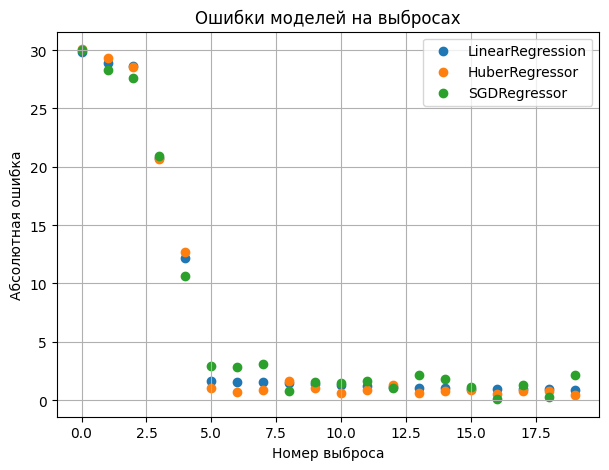

In [ ]:
errors_lr = np.abs(y_test - y_pred_lr)
errors_huber = np.abs(y_test - y_pred_huber)
errors_sgd = np.abs(y_test - y_pred_sgd)

# Get the actual index labels of the 20 largest errors from LinearRegression
outlier_labels = errors_lr.nlargest(20).index

plt.figure(figsize=(7,5))

# Use the 'outlier_labels' to select the corresponding errors from each Series
plt.scatter(range(len(outlier_labels)), errors_lr[outlier_labels], label="LinearRegression")
plt.scatter(range(len(outlier_labels)), errors_huber[outlier_labels], label="HuberRegressor")
plt.scatter(range(len(outlier_labels)), errors_sgd[outlier_labels], label="SGDRegressor")

plt.title("Ошибки моделей на выбросах")

plt.xlabel("Номер выброса")
plt.ylabel("Абсолютная ошибка")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
eps_values = [1.0, 1.35, 1.8, 2.5]

results = []

for eps in eps_values:

    model = HuberRegressor(epsilon=eps)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([eps, mse, mae, r2])

results_df = pd.DataFrame(results, columns=["epsilon","MSE","MAE","R2"])
results_df

,epsilon,MSE,MAE,R2
0,1.00,21.425511,1.202996,0.309111
1,1.35,21.389636,1.201661,0.310268
2,1.80,21.391518,1.200569,0.310207
3,2.50,21.390169,1.200840,0.310251


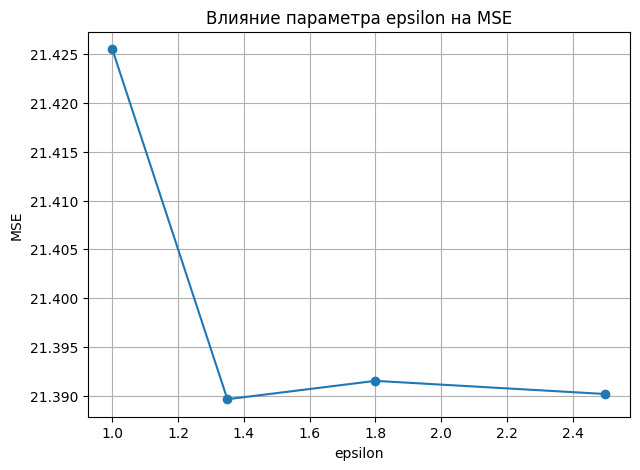

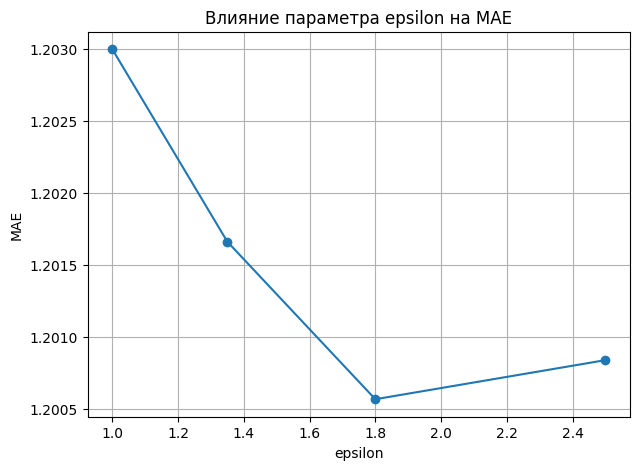

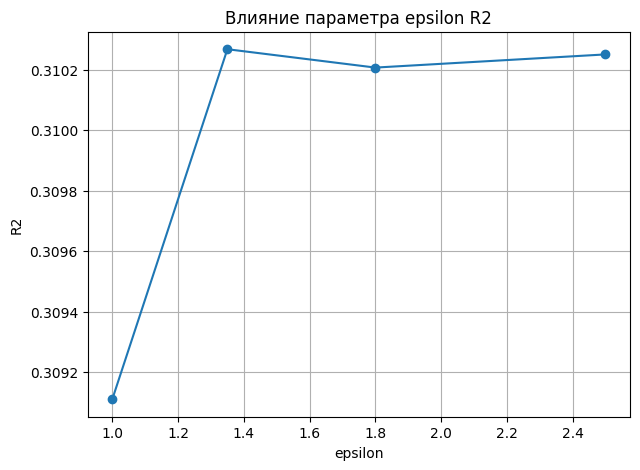

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(results_df["epsilon"], results_df["MSE"], marker='o')

plt.title("Влияние параметра epsilon на MSE")

plt.xlabel("epsilon")
plt.ylabel("MSE")

plt.grid(True)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(results_df["epsilon"], results_df["MAE"], marker='o')

plt.title("Влияние параметра epsilon на MAE")

plt.xlabel("epsilon")
plt.ylabel("MAE")

plt.grid(True)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(results_df["epsilon"], results_df["R2"], marker='o')

plt.title("Влияние параметра epsilon R2")

plt.xlabel("epsilon")
plt.ylabel("R2")

plt.grid(True)

plt.show()

**MSE**

Квадратичная функция потерь сильно увеличивает влияние больших ошибок. Это приводит к высокой чувствительности модели к выбросам, что может ухудшать точность предсказаний на данных с аномальными наблюдениями.

**Huber Loss**

Комбинирует квадратичную и линейную функции потерь. Для небольших ошибок используется квадратичная зависимость, а для больших — линейная. Благодаря этому модель сохраняет точность на нормальных данных и одновременно уменьшает влияние выбросов.

**Huber Loss в SGDRegressor**

Стохастический градиентный спуск позволяет эффективно обучать модель на больших наборах данных. Использование робастной функции потерь делает алгоритм устойчивым к шуму и аномальным значениям.